In [1]:
from langgraph.graph import MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [6]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [7]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [8]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

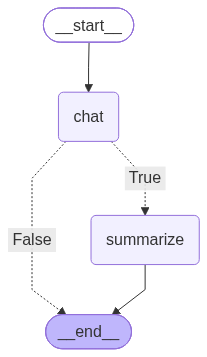

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [12]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [13]:
run_turn('Quantum Physics')
show_state()

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='78f5acc5-0dbc-4052-976c-714879947c3d')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : [{'type': 'text', 'text': '**Quantum physics** (also known as quantum mechanics or quantum theory) is the branch of physics that studies the behavior of matter and energy at the smallest scales—at the level of atoms and subatomic particles (like electrons, protons, and photons). \n\nWhile classical physics (Newtonian physics) explains how the big world works—like how a baseball flies or how planets orbit the sun—it completely breaks down at the microscopic level. In the quantum realm, the universe behaves in ways that seem bizarre, counterintuitive, and almost magical.\n\nHere is a breakdown of the core concepts, historical development, and mind-bending real-world implications of quantum physics.\n\n---\n\n### 1. The Big Shift: Why Do We Need Quantum Physics?\nAr

In [14]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='78f5acc5-0dbc-4052-976c-714879947c3d'), AIMessage(content=[{'type': 'text', 'text': '**Quantum physics** (also known as quantum mechanics or quantum theory) is the branch of physics that studies the behavior of matter and energy at the smallest scales—at the level of atoms and subatomic particles (like electrons, protons, and photons). \n\nWhile classical physics (Newtonian physics) explains how the big world works—like how a baseball flies or how planets orbit the sun—it completely breaks down at the microscopic level. In the quantum realm, the universe behaves in ways that seem bizarre, counterintuitive, and almost magical.\n\nHere is a breakdown of the core concepts, historical development, and mind-bending real-world implications of quantum physics.\n\n---\n\n### 1. The Big Shift: Why Do We Need Quantum Physics?\nAround the turn of the 20th century, scientists discovered that classical physics 

In [15]:
run_turn('What are some of Einstien"s famous work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='78f5acc5-0dbc-4052-976c-714879947c3d'), AIMessage(content=[{'type': 'text', 'text': '**Quantum physics** (also known as quantum mechanics or quantum theory) is the branch of physics that studies the behavior of matter and energy at the smallest scales—at the level of atoms and subatomic particles (like electrons, protons, and photons). \n\nWhile classical physics (Newtonian physics) explains how the big world works—like how a baseball flies or how planets orbit the sun—it completely breaks down at the microscopic level. In the quantum realm, the universe behaves in ways that seem bizarre, counterintuitive, and almost magical.\n\nHere is a breakdown of the core concepts, historical development, and mind-bending real-world implications of quantum physics.\n\n---\n\n### 1. The Big Shift: Why Do We Need Quantum Physics?\nAround the turn of the 20th century, scientists discovered that classical physics 

In [16]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='78f5acc5-0dbc-4052-976c-714879947c3d'), AIMessage(content=[{'type': 'text', 'text': '**Quantum physics** (also known as quantum mechanics or quantum theory) is the branch of physics that studies the behavior of matter and energy at the smallest scales—at the level of atoms and subatomic particles (like electrons, protons, and photons). \n\nWhile classical physics (Newtonian physics) explains how the big world works—like how a baseball flies or how planets orbit the sun—it completely breaks down at the microscopic level. In the quantum realm, the universe behaves in ways that seem bizarre, counterintuitive, and almost magical.\n\nHere is a breakdown of the core concepts, historical development, and mind-bending real-world implications of quantum physics.\n\n---\n\n### 1. The Big Shift: Why Do We Need Quantum Physics?\nAround the turn of the 20th century, scientists discovered that classical physics 